算术平均 Arithmetic Mean
$$
\bar{x} = \mu = \frac{1}{n}\sum_{i=1}^n x_i
$$


In [1]:
import numpy as np

data = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1])

arithmetic_mean = data.mean()
print(f'算术平均值 = {arithmetic_mean}')


算术平均值 = 2.7777777777777777


几何平均 Geometric Mean
$$
\bar{x} = (\prod_{i=1}^n x_i)^{\frac{1}{n}}
$$

In [2]:
geometric_mean = data.prod() ** (1 / data.size)
print(f'几何平均 = {geometric_mean}')


几何平均 = 2.423131275401765


$$
\text{方差 (Variance): 统计量, 用于衡量数据点与数据均值之间的差异程度} \\
\sigma^2 = \dfrac{1}{n} \sum_{i=1}^n (x_i - \mu)^2 \\
\quad \\
\mu \text{ 是总体的均值} \\
\quad \\
\text{样本方差 (Sample Variance): 统计量, 用于衡量样本数据点与样本均值之间的差异程度} \\
S^2 = \dfrac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2 \\
\quad \\
\bar{x} \text{ 是样本的均值} \\
\text{这里的-1是贝塞尔校正项 (Bessel's Correction), 样本数据仅是总体的一个子集, 它不包含所有信息} \\
\text{因此样本方差往往会低估总体方差, 为了弥补这一差异, 引入了贝塞尔校正项, 将除数从n改为n-1, 从而更准确地估计总体方差} \\
$$

In [3]:
variance = data.var()
print(f'方差 = {variance}')

sample_variance = data.var(ddof=1)
print(f'样本方差 = {sample_variance}')

方差 = 1.7283950617283952
样本方差 = 1.9444444444444446


$$
\text{正态分布的概率密度函数} \\
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
\quad \\
\mu: \text{均值} \\
\sigma^2: \text{方差} \\
\text{标准正态分布: } \mu = 0, \sigma^2 = 1
$$

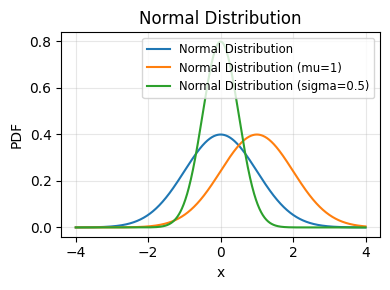

In [4]:
from matplotlib import pyplot as plt
import scipy.stats as stats

def plot_nicely():
    for ax in plt.gcf().get_axes():
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize='small')
    plt.tight_layout()

normal_distribution = stats.norm()
x = np.linspace(-4, 4, 1000)
y = normal_distribution.pdf(x)
plt.figure(figsize=(4,3))
plt.plot(x, y, label=f'Normal Distribution')
plt.xlabel('x')
plt.ylabel('PDF')
plt.title('Normal Distribution')

# adjust mu
mu = 1
normal_distribution_mu = stats.norm(loc=mu)
y = normal_distribution_mu.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (mu={mu})')

# adjust sigma
sigma = 0.5
normal_distribution_sigma = stats.norm(scale=sigma)
y = normal_distribution_sigma.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (sigma={sigma})')

plot_nicely()
plt.show()


$$
\text{卡方分布的概率密度函数} \\
\quad \\
\chi^2(x; df=1) = \sum_{i=1}^n Z_i^2 \\
$$

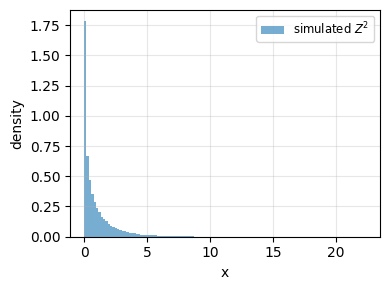

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

rng = np.random.default_rng(0)
n = 200000
z = rng.normal(0, 1, n)
x_sim = z**2  # Z^2 -> chi-square(1)

df = 1
x = np.linspace(0, chi2.ppf(0.999, df), 800)
pdf = chi2.pdf(x, df)

plt.figure(figsize=(4,3))
# plt.plot(x_sim, linewidth=2, label=r"theory $\chi^2_1$")
plt.hist(x_sim, bins=120, density=True, alpha=0.6, label="simulated $Z^2$")
# plt.ylim(0, 0.05)
# plt.plot(x, pdf, linewidth=2, label=r"theory $\chi^2_1$")
# plt.title(r"Simulation: $Z^2$ vs $\chi^2_1$")
plt.xlabel("x")
plt.ylabel("density")
plot_nicely()
plt.show()

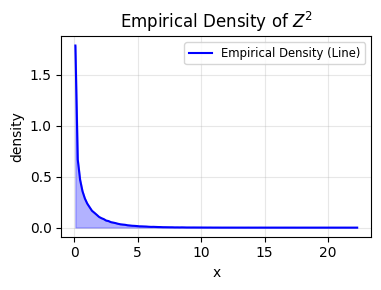

In [6]:
# 手动计算直方图和密度函数
counts, bins = np.histogram(x_sim, bins=120)
manual_density = counts / (counts.sum() * np.diff(bins))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(4, 3))
plt.plot(bin_centers, manual_density, 'b-', label="Empirical Density (Line)")
plt.fill_between(bin_centers, manual_density, alpha=0.3, color='blue')
plt.title("Empirical Density of $Z^2$")
plt.xlabel("x")
plt.ylabel("density")
plot_nicely()
plt.show()

$$
\text{恒等式} \\
\bar{x} = \frac{1}{n} \sum x_i \\
\sum x_i = n\bar{x} \\
\quad \\

\sum (x_i - \bar{x})^2 = \sum (x_i - \bar{x})(x_i - \bar{x}) \\
= \sum (x_i^2 - 2x_i\bar{x} + \bar{x}^2) \\
= \sum x_i^2 - \sum 2x_i\bar{x} + \sum \bar{x}^2 \\
\quad \\

\text{处理第二项} \\
\sum 2x_i\bar{x} = 2\bar{x}\sum x_i = 2n\bar{x}^2 \\
\quad \\

\text{处理第三项} \\
\sum \bar{x}^2 = n\bar{x}^2 \\
\quad \\

\text{最终结果} \\
\sum (x_i - \bar{x})^2 = \sum x_i^2 - 2n\bar{x}^2 + n\bar{x}^2 \\
= \sum x_i^2 - n\bar{x}^2 \\
= \sum x_i^2 - \frac{1}{n}(\sum x_i)^2 \\
$$

In [7]:
((data - arithmetic_mean)**2).sum() == (data**2).sum() - 1 / data.size * (data.sum()**2)


np.True_

$$
\text{协方差 Covariance: 协方差表示X, Y随机变量的变化趋势是否一致} \\
COV > 0: \text{说明X和Y正相关, 即当X增加时, Y也增加} \\
COV < 0: \text{说明X和Y负相关, 即当X增加时, Y减少} \\
COV = 0: \text{说明X和Y独立, 即X的变化不影响Y的变化} \\
COV[x, y] = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
\text{样本协方差计算时, 分母为n - 1. 总体协方差计算时, 分母为n.} \\ 
$$

In [8]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 4, 5, 7, 9])

# np.cov 给的是矩阵
# [Cov[X, X], Cov[X, Y]]
# [Cov[Y, X], Cov[Y, Y]]

sample_COV = 1 / (len(x) - 1) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
sample_npCOV = np.cov(x, y, ddof=1)[0, 1]

total_COV = 1 / len(x) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
total_npCOV = np.cov(x, y, ddof=0)[0, 1]

print(f'sample_COV: {sample_COV}')
print(f'sample_npCOV: {sample_npCOV}')
print(f'total_COV: {total_COV}')
print(f'total_npCOV: {total_npCOV}')


sample_COV: 2.75
sample_npCOV: 2.75
total_COV: 2.2
total_npCOV: 2.2


$$
\text{自协方差 (Auto Covariance)} \\
COV[x_t, x_{t + k}] = \frac{1}{n} \sum_{t=k}^{n} (x_t - \bar{x})(x_{t + k} - \bar{x}) \\
\text{k: 是滞后阶数 (Lags)或滞后步长或时间数} \\ \quad \\
\text{上面的自协方差是有偏估计，也就是真实数据其实只有k个，但平均时候用n个} \\
\text{所以无偏估计为} \\
COV[x_t, x_{t + k}] = \frac{1}{n - k} \sum_{t=k}^{n} (x_t - \bar{x})(x_{t + k} - \bar{x}) \\ \quad \\
\text{纯随机（白噪声）：如果你画出的散点图，除了 k=0（即方差）很大之外，其他的点都几乎在 0 附近晃荡} \\
\text{说明这个序列是纯随机的，不可预测。} \\ \quad \\
\text{有规律的序列：如果散点图呈现出平滑下降或震荡的趋势} \\
\text{说明历史数据对未来有参考价值，你可以用它来建立预测模型。} \\ \quad \\

\text{为什么要有（有偏估计）？} \\
\text{在实际的统计学和时间序列软件（如 R 或 Python 的 statsmodels）中，默认通常使用有偏估计（分母为 N）} \\
\text{正定性（Positive Definiteness）：使用分母 N可以保证得到的自协方差矩阵是“正定”的。} \\
\text{这意味着你算出的方差永远不会出现数学上的矛盾（比如算出负的方差）。} \\ \quad \\
\text{均方误差更小：虽然它有偏差，但在很多情况下，它的整体误差（均方误差）反而比无偏估计更小，尤其是在滞后阶数 k 较大时。} \\ \quad \\
\text{一致性：随着样本量 N 变得非常大，这两个公式的结果会趋于一致。} \\ \quad \\
\text{有偏估计大多在软件计算、工程实践中运用。而无偏估计在理论研究中更常用。} \\ \quad \\
$$


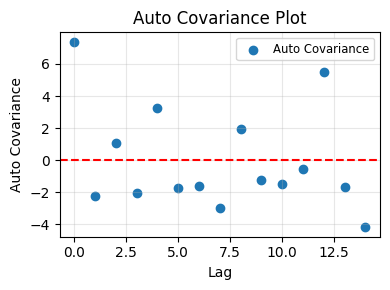

In [9]:
def calc_auto_cov(x, k):
    n = len(x)
    x_mean = np.mean(x)
    auto_cov = np.sum((x[:n-k] - x_mean) * (x[k:] - x_mean)) / (n - k)
    return auto_cov

x = np.array([1, 2, 6, 7, 2, 5, 7, 9, 4, 8, 2, 9, 1, 5, 6])
x_mean = np.mean(x)
auto_covs = [calc_auto_cov(x, k) for k in range(len(x))]
plt.figure(figsize=(4, 3))
plt.scatter(range(len(x)), auto_covs, label="Auto Covariance")
plt.axhline(0, color='r', linestyle='--')
plt.title("Auto Covariance Plot")
plt.xlabel("Lag")
plt.ylabel("Auto Covariance")
plot_nicely()
plt.show()

$$
\text{自相关系数 (Autocorrelation Coefficient)} \\
\rho_k = \frac{COV[x_t, x_{t + k}]}{\gamma_0} = \frac{\gamma_k}{\gamma_0} \\ \quad \\
\rho_k \text{ 是第 k 个滞后的自相关系数} \\
COV[x_t, x_{t + k}] \text{ 是第 k 个滞后的自协方差} \\ \quad \\
\text{所有的自相关系数组成的线，就叫做自相关函数 (AutoCorrelation Function)} \\
\text{ACF 实际上是} x_t \text{ 受到 } x_{t + 1}, x_{t + 2}, ..., x_{t + k - 1} \text{ 的影响} \\
\text{而这些 k - 1 个随机变量又都和 } x_{t + k} \text{ 具有相关关系} \\
\text{所以自相关系数里面实际掺杂了其他变量对 } x_t \text{ 与 } x_{t + k} \text{ 的影响} \\
$$

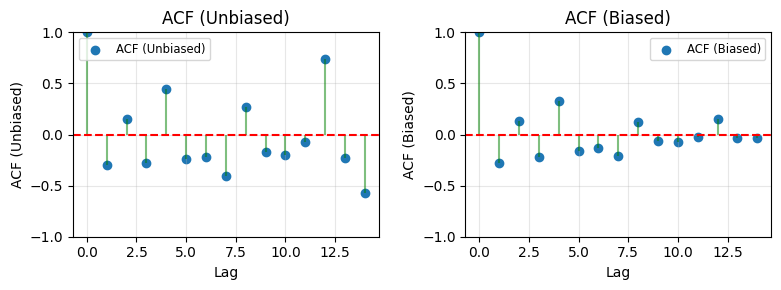

In [ ]:
from statsmodels.tsa.stattools import acf

def calc_auto_correlation_coefficient(x, k):
    n = len(x)
    x_mean = np.mean(x)
    auto_correlation_coefficient = np.sum((x[:n-k] - x_mean) * (x[k:] - x_mean)) / (n - k)
    return auto_correlation_coefficient

x = np.array([1, 2, 6, 7, 2, 5, 7, 9, 4, 8, 2, 9, 1, 5, 6])
x_mean = np.mean(x)
acfs = [calc_auto_correlation_coefficient(x, k) / calc_auto_correlation_coefficient(x, 0) for k in range(len(x))]

fig, axs = plt.subplots(1, 2, figsize=(8, 3))
axs[0].scatter(range(len(x)), acfs, label="ACF (Unbiased)")
for i in range(len(x)):
    axs[0].vlines(i, 0, acfs[i], color='g', alpha=0.5)
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title("ACF (Unbiased)")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("Lag")
axs[0].set_ylabel("ACF (Unbiased)")

acf_func = acf(x, nlags=len(x)-1)
axs[1].scatter(range(len(x)), acf_func, label="ACF (Biased)")
for i in range(len(x)):
    axs[1].vlines(i, 0, acf_func[i], color='g', alpha=0.5)
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title("ACF (Biased)")
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel("Lag")
axs[1].set_ylabel("ACF (Biased)")

plot_nicely()
plt.show()

$$
\text{偏自相关系数 (Partial Autocorrelation Coefficient)} \\ \quad \\
\text{有四种方式计算偏自相关系数: } \\
\text{1. 把ACF 运用到 尤尔-沃克(Yule-Walker) 方程，再用矩阵求解法 (Cramer's Rule) 或者 递归算法 (Durbin-Levinson Algorithm)求解} \\
\text{2. 回归分析法 (Regression Approach)} \\
\text{3. 残差相关法 (Residual Correlation)} \\
\text{4. 最大似然估计法 (Maximum Likelihood Estimation)} \\
$$

In [61]:
from scipy.linalg import toeplitz

# 把 ACF 运用到 尤尔-沃克(Yule-Walker) 方程
yule_walker_eq = toeplitz(acfs[:-1])
phi = acfs[1:] @ np.linalg.inv(yule_walker_eq)
print(f'phi = {phi}')

phi = [-0.44162759 -5.40096665 -5.17234404 -1.62226443 -2.07139608 -1.01070009
  0.49332708 -1.38147021 -4.32667953 -3.88522767 -2.19433814 -3.01839971
 -0.59588492  2.79783399]


In [62]:
# apply Cramer's Rule
numerator = yule_walker_eq.copy()
numerator[:, -1] = acfs[1:]
denominator = yule_walker_eq
np.linalg.det(numerator) / np.linalg.det(denominator)

np.float64(2.797833994670908)

In [64]:
def visual_durbin_levinson(acfs, p):
    phi = np.zeros((p, p))
    rho = acfs 
    
    print(f"🚀 开始拟合 AR({p}) 模型...")
    print("-" * 50)
    
    # 第 1 阶初始化
    phi[0, 0] = rho[1]
    print(f"阶数 k=1: 直接取自相关系数 ρ₁")
    print(f"   φ₁₁ = {phi[0,0]:.4f}")
    
    # 递推
    for k in range(2, p + 1):
        # 计算当前阶的偏自相关系数 (PACF)
        prev_coeffs = phi[k-2, :k-1]
        relevant_rhos_num = rho[1:k][::-1]
        relevant_rhos_den = rho[1:k]
        
        num = rho[k] - np.dot(prev_coeffs, relevant_rhos_num)
        den = 1 - np.dot(prev_coeffs, relevant_rhos_den)
        phi_kk = num / den
        
        phi[k-1, k-1] = phi_kk
        
        print(f"\n阶数 k={k}:")
        print(f"   Step 1: 计算主系数 (PACF) φ_{k}{k}")
        print(f"     φ_{k}{k} = ({rho[k]:.4f} - 修正项) / 误差压缩项 = {phi_kk:.4f}")
        
        # 更新之前的系数
        print(f"   Step 2: 利用 φ_{k}{k} 修正前 {k-1} 个系数")
        for j in range(1, k):
            old_val = phi[k-2, j-1]
            phi[k-1, j-1] = old_val - phi_kk * phi[k-2, k-j-1]
            print(f"     φ_{k}{j} = {old_val:.4f} - ({phi_kk:.4f} * {phi[k-2, k-j-1]:.4f}) -> {phi[k-1, j-1]:.4f}")
            
    print("-" * 50)
    print(f"✅ 最终 AR({p}) 系数向量: {phi[p-1]}")
    return phi[p-1]

# 测试数据：假设一组自相关系数
example_acfs = [1.0, 0.8, 0.6, 0.4] 
visual_durbin_levinson(acfs, len(acfs) - 1)


🚀 开始拟合 AR(14) 模型...
--------------------------------------------------
阶数 k=1: 直接取自相关系数 ρ₁
   φ₁₁ = -0.2982

阶数 k=2:
   Step 1: 计算主系数 (PACF) φ_22
     φ_22 = (0.1490 - 修正项) / 误差压缩项 = 0.0660
   Step 2: 利用 φ_22 修正前 1 个系数
     φ_21 = -0.2982 - (0.0660 * -0.2982) -> -0.2785

阶数 k=3:
   Step 1: 计算主系数 (PACF) φ_33
     φ_33 = (-0.2758 - 修正项) / 误差压缩项 = -0.2367
   Step 2: 利用 φ_33 修正前 2 个系数
     φ_31 = -0.2785 - (-0.2367 * 0.0660) -> -0.2629
     φ_32 = 0.0660 - (-0.2367 * -0.2785) -> 0.0000

阶数 k=4:
   Step 1: 计算主系数 (PACF) φ_44
     φ_44 = (0.4439 - 修正项) / 误差压缩项 = 0.3513
   Step 2: 利用 φ_44 修正前 3 个系数
     φ_41 = -0.2629 - (0.3513 * -0.2367) -> -0.1797
     φ_42 = 0.0000 - (0.3513 * 0.0000) -> 0.0000
     φ_43 = -0.2367 - (0.3513 * -0.2629) -> -0.1443

阶数 k=5:
   Step 1: 计算主系数 (PACF) φ_55
     φ_55 = (-0.2365 - 修正项) / 误差压缩项 = -0.0405
   Step 2: 利用 φ_55 修正前 4 个系数
     φ_51 = -0.1797 - (-0.0405 * 0.3513) -> -0.1655
     φ_52 = 0.0000 - (-0.0405 * -0.1443) -> -0.0058
     φ_53 = -0.1443 - (-0.0405 *

array([-0.44162759, -5.40096665, -5.17234404, -1.62226443, -2.07139608,
       -1.01070009,  0.49332708, -1.38147021, -4.32667953, -3.88522767,
       -2.19433814, -3.01839971, -0.59588492,  2.79783399])

$$
\text{离散型随机变量的数学期望 (Expectation)} \\
E(X) = \sum_{i=1}^n x_i p(x_i) \\
\quad \\
\text{连续型随机变量的数学期望 (Expectation)} \\
E(X) = \int_{-\infty}^{\infty} x f(x) dx \\
$$

In [11]:
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
discret_E = np.sum(x * p)
discret_E == x.mean()

np.True_

Mathematical Expectation: 1.3333333333333335


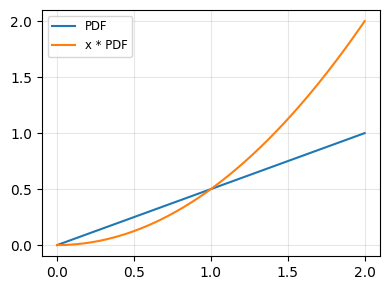

In [12]:
from scipy.integrate import quad

x = np.linspace(0, 2, 400)

# 1. 定义合法的概率密度函数 (PDF)
def f(x):
    return 0.5 * x

# 2. 定义期望的被积函数：x * f(x)
def expectation_integrand(x):
    return x * f(x)

# 3. 使用积分函数计算期望
# quad 函数返回 (积分值, 误差估计)
expected_value, error = quad(expectation_integrand, 0, 2)

print(f"Mathematical Expectation: {expected_value}") 
# 结果为 1.333... (即 4/3)
# 注意：这比区间的算术中点 1.0 更偏右，因为右侧的概率密度更大。

plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label='PDF')
plt.plot(x, expectation_integrand(x), label='x * PDF')
plot_nicely()
plt.show()
